In [ ]:
import os
import logging

# import keras.backend as k  # Removed Keras backend
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests
# import tensorflow as tf  # Removed as we're using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# from gradientAttack import GradientAttack, ProjectedGradientDescent, FastGradientMethod
# from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from io import BytesIO
from IPython.display import clear_output
# from keras import optimizers  # Removed Keras optimizers
# from keras.datasets import mnist  # Will use torchvision.datasets instead
# from keras.layers import Activation, Conv2D, Dense, Flatten, MaxPooling2D  # Removed Keras layers
# from keras.models import load_model, Model, Sequential  # Removed Keras models
# from keras.utils import to_categorical  # Will use torch.nn.functional.one_hot instead
from PIL import Image
from sklearn.metrics import confusion_matrix
# from tensorflow.python.ops.parallel_for.gradients import batch_jacobian  # Will use torch.autograd instead
# from tqdm.keras import TqdmCallback  # Removed Keras callback
from tqdm.notebook import tqdm

# Remove tensorflow warning suppression as it's no longer needed
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# logging.getLogger('tensorflow').setLevel(logging.FATAL)


#suppress tensorflow warnings
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# logging.getLogger('tensorflow').setLevel(logging.FATAL)

In [34]:
from tqdm import tqdm

In [6]:
url = 'http://127.0.0.1:9000/predict'

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

100%|██████████| 9.91M/9.91M [00:11<00:00, 852kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 309kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.19MB/s]


In [15]:
def display_sample(sample):
    """
    Display a sample from the MNIST dataset
    :param sample: PyTorch tensor or tuple of (tensor, label)
    """
    # Handle both single tensor and (tensor, label) tuple inputs
    if isinstance(sample, tuple):
        image, label = sample
    else:
        image = sample
        label = None
    
    # Convert PyTorch tensor to numpy and denormalize
    image_array = ((image.squeeze() * 0.3081) + 0.1307) * 255
    image_array = image_array.numpy().astype(np.uint8)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image_array, cmap='gray')
    if label is not None:
        plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

Oracle prediction: 0
True label: 0


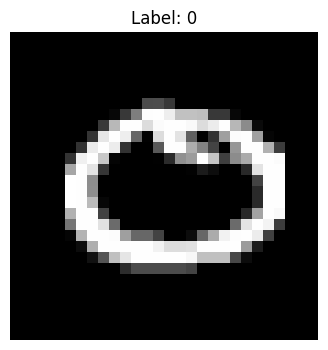

In [20]:
def query_oracle(sample):
    """
    Send a single classification query to the oracle
    :param sample: PyTorch tensor or tuple of (tensor, label)
    :return: predicted class as integer
    """
    # Handle both single tensor and (tensor, label) tuple inputs
    if isinstance(sample, tuple):
        sample = sample[0]  # Get just the image tensor
    
    # Convert PyTorch tensor to numpy array and prepare for PIL
    # Denormalize and convert to uint8 format
    image_array = ((sample.squeeze() * 0.3081) + 0.1307) * 255
    image_array = image_array.numpy().astype(np.uint8)
    
    buffer = BytesIO()
    image = Image.fromarray(image_array)
    image.save(buffer, format='PNG')
    files = {'file': ('image.png', buffer.getvalue(), 'image/png')}
    response = requests.post(url, files=files)
    return int(response.json()['prediction'])

# Example usage:
sample = train_dataset[np.random.randint(len(train_dataset))]
print(f"Oracle prediction: {query_oracle(sample)}")
print(f"True label: {sample[1]}")
display_sample(sample)

In [37]:
def get_oracle_predictions(dataset):
    """
    Call oracle function on a PyTorch dataset
    :param dataset: PyTorch dataset
    :return: predicted class as numpy array (int) with shape (-1)
    """
      # Use standard tqdm instead of notebook version
    
    preds = []
    for i in tqdm(range(len(dataset)), desc="Getting predictions"):
        preds.append(query_oracle(dataset[i]))
    return np.array(preds)

In [38]:
test_subset = torch.utils.data.Subset(test_dataset, np.random.choice(len(test_dataset), 1000, replace=False))

In [39]:
pred = get_oracle_predictions(test_subset)

Getting predictions: 100%|██████████| 1000/1000 [00:02<00:00, 436.86it/s]
